# EX1: Electromagnetic Skin Depth of Metals

## Session 1: Jan 13th, 2026

#### Today's goals
- Understand the purpose of the lab, reconcile with derivations from pre-lab 
- Get familiar with remotely controlling the function generator (Agilent 33120A) and the oscilloscope (RIGOL DS1022Z)

#### High-level theory
- Skin depth is a phenomenon that happens when electromagnetic radiation tries to penetrate a metal
- Measures the depth at which EM field is attenuated by 1/e = ~37% compared to its surface value 
- Time-varying EM fields cause large screening (eddy) currents in the metal which forces the fields to concentrate near the surface 
- The amount/efficiency of this shielding depends on permeability, conductivity, and heavily on frequency 
- As radiation frequency ↑, shielding ↑ and skin depth ↓ - but only for a certain lowish-frequency range, skin effect does NOT apply to high energy waves like x-rays

#### PI setup

- Following instructions on Github wiki to set everything up
- Had to restart the rpi, and then was able to log into rpi using cwl username and password 
- SSH also works in command-line: 
    ```Bash
    ssh evinli@p400-60.phas.ubc.ca
    ```
- Ahhh I really wanted to use the VSCode remote SSH extension, but seems like it doesn't work, edit: this is a known issue, something about how the rpi is hosted on ubc network and firewall blocks `~/.vscode-server` from being installed

#### Dev workflow

- In lieu of no VSCode remote SSH, I think I'll just do all my dev work/scripting on my laptop locally 
- I'll clone the repo on the rpi once, and then just scp any changes from my laptop, eg: 
    ```Bash
    scp ~/Dev/enph_352/evin-li-EX1-skin/src/intro.py evinli@p400-60.phas.ubc.ca:~/Dev/evin-li-EX1-skin/src
    ```
- Changes on laptop should also be pushed periodically during lab sesh to Github 
- In terms of data collected on the rpi, I think I can also just scp them to my laptop:
    ```Bash
    rsync -aEvP ~/Dev/evin-li-EX1-skin/data/ evinli@10.33.24.148:~/Dev/enph_352/evin-li-EX1-skin/data/ 
    ```
    - ^For some reason I can't ping my mac from the rpi... this might also a firewall or VPN issue
- Another option is to just use `cat` and to copy-paste the contents of a csv file to my laptop

#### Intro/prep task

- I think I've actually used this function gen and oscilloscope before actually
- Figured out how to set the output function and then read the measurements from the oscilloscope display (NICE)
- Next step is to see if I can control them remotely via the `scpi_instruments.py` submodule 
- Okay did some rejigging in the template scripts (renamed `skin.py` to `src/intro.py` and updated `scope_num` to 2)
- Copying it over to the rpi and running
- Oop note to self: make sure to use `python3` and not `python` (which defaults to Python 2.0) - f-string formatting doesn't exist yet in Python 2.0
- Got the following output for a 10Khz, 8Vpp waveform

    ```Bash
    Finding IDN...
    HEWLETT-PACKARD,33120A,0,8.0-5.0-1.0

    Testing
    +0

    ('9.9E37\n', '9.9E37\n', '9.9E37\n')
    ```
- Hmm, that doesn't seem quite right - will try again after resetting scope + func generator next session, these seem to be a NaN invalid readings

## Session 2: Jan 20th, 2026

#### Today's goals
- Retry the intro/setup task to make sure we can 1) connect to function generator and set output freq and amplitude, and 2) connect to oscilloscope, adjust voltage/time scales, and read output peak-to-peak voltage + phase differences
- Measure dimensions of copper and aluminum pipes 
- Modify `src/sweep.py` to sweep across 100Hz - 80Khz and collect data as `.csv` files for aluminum, copper, and air (control group)

#### Intro/prep task (retry)
- Okay last time we were seeing some weirdly large, out-of-bound NaN readings from the scope
- First thing I did was power-cycle the function generator and oscilloscope 
- Hmm same thing is still happening (my amplitudes and phase shifts are still coming back as 9.9E37)
- Wait is this because I don't have the receive RF coil place inside the larger tarnsmit RF coil?
- The turn ratio of the transmit (TX) vs. receive coil (RX) means voltage should be stepped down (right??)
- Yep, searching online for the formula, the relationship between number of turns vs. voltage should be:
$\frac{V_p}{V_s} = \frac{N_p}{N_s}$ where TX coil is the primary one, RX coil is seconday
- Hmm let's look at our all known input parameters

1. Transmit coil:
    - Diameter: 2" (5.08cm)
    - Turn density: 10 turns/cm
    - Length: 6"

2. Receive coil:
    - Diameter: 3/8" (0.95cm)
    - Total turns: 200 turns
    - Length: ~20cm (if tightly wound)
    - Located coaxially inside the transmit coil

- Okay, understanding this a bit better now 
- RX coil should be placed in the centre of TX coil (~ 3" in) in order to maximize RX signal strength 

    <img src="../assets/coil_placement.jpg" height="300" alt="Relative RX/TX coil placement"/>


- `src/intro.py` is set up as follows:
    - Wave type: sine
    - Amplitude: 8.0Vpp
    - Frequency: 10kHz (period: 100us)
    - Scope time scale: 20us per div (12 divs = ~2 cycles)

- Getting sensible readings out now, which also matches the numbers on the oscilloscope display 
    ```Bash
    evinli@p400-60:~/Dev/evin-li-EX1-skin $ python3 src/intro.py 
    Finding IDN...
    HEWLETT-PACKARD,33120A,0,8.0-5.0-1.0

    Testing
    +0

    ('3.360000e-01\n', '1.281000e+01\n', '2.736000e+01\n')
    ```

- Measurements:
    - Channel 1 amplitude: 0.336Vpp (this is RX signal)
    - Channel 2 amplitude: 13Vpp (this is TX signal)... 
    - Phase shift: 27.36deg

- Wait why is channel 2 not reading its 8Vpp set point... realized this is likely due to mutual inductance and power reflections from impedance mismatches causing the input voltage seems to increase with frequency ($Z = iwL$)
- This means RX experiences voltage step-down of ~35x

    <img src="../assets/rx_tx_scope_readings.jpg" width="400" alt="Manual Vpp and phase display readings"/>



#### Important formulas 
- To understand which quanitites we actually want to monitor and compare against expected/analytical values, let's write down some equations
- At a high-level, we are measuring the phase + amplitude of the alternating magnetic field inside vs. outside of the pipe
- The 2nd lab manual gives us the following equations:
    - Amplitude ratio of H field: $$\frac{H_i}{H_o} = \rho e^{i\phi}$$ 
    
    - Phase shift: $$\phi = k_o (R_2 - R_1) + \arctan \left( \frac{R_1 k_o}{2 + R_1 k_o} \right)$$
    
        where
    
        $$\rho = 2\sqrt{\frac{R_2}{R_1}} \left\{ \frac{e^{-k_o(R_2-R_1)}}{\sqrt{1 + R_1 k_o + \frac{R_1^2 k_o^2}{2}}} \right\}$$
        $$k_o = \sqrt{\frac{\omega \sigma \mu}{2}}$$

        - $H_o$ = magnetic field outside the pipe
        - $H_i$ = magnetic field inside the pipe
        - $R_1$ = inner radius of pipe
        - $R_2$ = outer radius of pipe
        - $\sigma$ = conductivity of metal 
        - $\mu$ = permeability of the metal
        - $w$ = angular frequency
        - $k_o(R_2 - R_1) \leq 1$ = high-frequency approx. breakdown

#### Aggregating known parameters
- Using calipers to measure the inner and outer radii of the two metal pipes (alumininum and copper)
- Not really sure what the other materials are - one feels like plastic, the other might be steel (EDIT: the 2nd lab manual confirms its steel)

- Aluminum
    - $\sigma = 3 \cdot 10^7 \text{ } \Omega^{-1} \text{m}^{-1} $ (from [online table](https://www.thoughtco.com/table-of-electrical-resistivity-conductivity-608499))
    - $\mu = 1.256 \cdot 10^{-6} \text{ } \text{H} \text{ m}^{-1}$ (from [online table](https://en.wikipedia.org/wiki/Permeability_(electromagnetism)))
    - $D_1 = (21.61 \pm 0.005) \cdot 10^{-3} \text{ m}$ (measured)
    - $D_2 = (25.59 \pm 0.005) \cdot 10^{-3} \text{ m}$ (measured)

- Copper
    - $\sigma = 5.96 \cdot 10^7 \text{ } \Omega^{-1} \text{m}^{-1} $ (from [online table](https://www.thoughtco.com/table-of-electrical-resistivity-conductivity-608499))
    - $\mu = 1.256 \cdot 10^{-6} \text{ } \text{H} \text{ m}^{-1}$ (from [online table](https://en.wikipedia.org/wiki/Permeability_(electromagnetism)))
    - $D_1 = (25.55 \pm 0.005) \cdot 10^{-3} \text{ m}$ (measured)
    - $D_2 = (28.61 \pm 0.005) \cdot 10^{-3} \text{ m}$ (measured)

#### Calculating breakdown frequency
From the lab manual, we know that the above^ formulas only hold true when $k_o(R_2 - R_1) \le 1$. Rearranging, we can solve for the breakdown frequency using: 
$$f \leq \frac{1}{\pi \sigma \mu (R_2 - R_1)^2}$$


In [130]:
import numpy as np

al_sig = 3e7
al_mu = 1.256e-6
al_outer_r = 25.59e-3 / 2
al_inner_r = 21.61e-3 / 2

cu_sig = 5.96e7
cu_mu = 1.256e-6
cu_outer_r = 28.61e-3 / 2
cu_inner_r = 25.55e-3 / 2

al_breakdown = 1 / (np.pi * al_sig * al_mu * np.pow(al_outer_r - al_inner_r, 2))
print(f"Aluminium breakdown freq: {al_breakdown:.3f} Hz")

co_breakdown = 1 / (np.pi * cu_sig * cu_mu * np.pow(cu_outer_r - cu_inner_r, 2))
print(f"Copper breakdown freq: {co_breakdown:.3f} Hz")



Aluminium breakdown freq: 2133.207 Hz
Copper breakdown freq: 1816.483 Hz


#### Data collection 
- Modifying `src/sweep.py` to take measurements + save to CSV file
- I collected a few sets of data with around ~80 samples each (approx. every 1KHz) with an input voltage of 8Vpp, this takes 10 mins to finish running
- Made sure to start frequency sweep before breakdown frequencies calculated above so we can analyze the behavior there as well
- Just to sanity check if my data looks good, I'm gonna plot them really quickly below using matplotlib

   Freq (Hz)  Vpp_RX (V)  Vpp_TX (V)  Phase_Shift (deg)
1    1124.36      0.0487    7.880000           75.59999
3    3173.08      0.1392    8.889999           56.38554
4    4197.44      0.1786    9.450000           48.96000
5    5221.79      0.2140   10.140000           39.60000


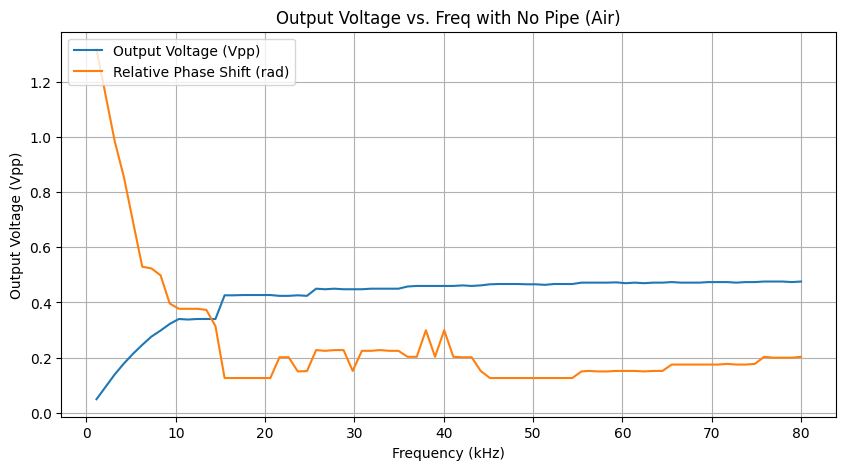

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

air_data = '../data/2026-01-20_13_55_01_air.csv'
df = pd.read_csv(air_data)
df = df[1:]
df = df[df['Vpp_RX (V)'] < 1E37]
print(df.head(4))

plt.figure(figsize=(10, 5))
plt.plot(df['Freq (Hz)'] / 1000, df['Vpp_RX (V)'], label='Output Voltage (Vpp)')
# plt.plot(df['Freq (Hz)'], df['Vpp_TX (V)'], label='TX Coil Voltage (Vpp)')
plt.plot(df['Freq (Hz)'] / 1000, df['Phase_Shift (deg)'] * (np.pi / 180), label='Relative Phase Shift (rad)')

plt.xlabel('Frequency (kHz)')
plt.ylabel('Output Voltage (Vpp)')
plt.title('Output Voltage vs. Freq with No Pipe (Air)')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()



#### Data collection optimizations
- One thing I'm noticing is that I'm frequently getting `9.9E37` NaN readings, especially when it comes to the alumininum and copper pipes
- I belive this happens because we try to read a measurement before the hardware acquisition system has actually stabilized, the scope is reporting "READY" but I guess it's not really  
- Rigol is complaining that it can't see the waveform well enough to do math on it to compute phase shift
- The issue might be the autoscale function
- Seems like we aren't sampling over many periods, could that be why it's so difficult to compute phase shift? 
- Okay increased time scale to show at least 5 periods, this gives RIGOL more zero-crossings to average across for the `:MEAS:ITEM? RPH` command
- One thing I was confused about was whether data shown on screen = data used in calculations 
    - Answer is YES, benchtop scopes usually use data points that are current stored in the "visible" buffer on the screen for automated measurements like phase, Vpp, and freq 
    - Aka. if the signal is clipped, your measurements will be wrong
- Adding this snippet to my `src/sweep.py` script
    ```Python
    # Adjust time scale to store more data in visible buffer for computations
    num_cycles_to_show = 5  # Increase this to see more periods
    period = 1 / freq
    t_scale = (num_cycles_to_show * period) / 12
    scope.write(":TIM:SCAL {:.2E}".format(t_scale))
    ```

#### Visualizing raw data

   Freq (Hz)  Vpp_RX (V)  Vpp_TX (V)  Phase_Shift (deg)
2    2148.72      0.0232        8.18          -14.40000
3    3173.08      0.0228        8.54          -39.03615
4    4197.44      0.0220        8.98          -51.84000
5    5221.79      0.0209        9.57          -64.80000


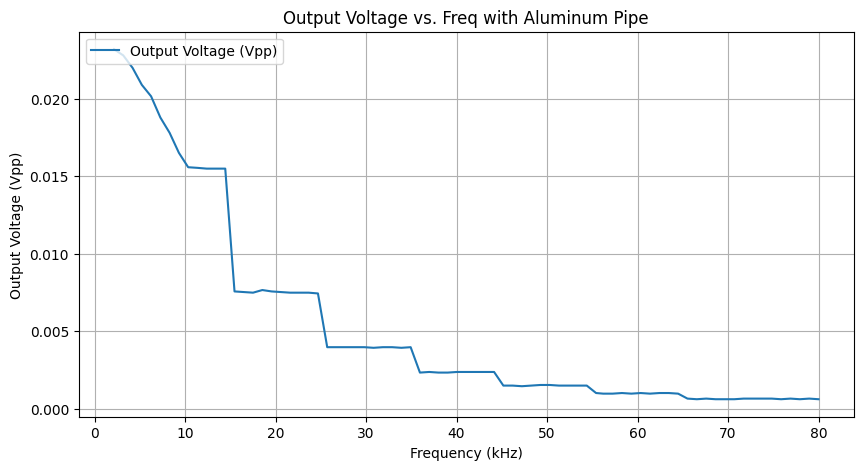

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

air_data = '../data/2026-01-27_11_28_26_aluminum.csv'
df = pd.read_csv(air_data)
df = df[1:]
df = df[df['Vpp_RX (V)'] < 1E37]
print(df.head(4))

plt.figure(figsize=(10, 5))
plt.plot(df['Freq (Hz)'] / 1000, df['Vpp_RX (V)'], label='Output Voltage (Vpp)')
# plt.plot(df['Freq (Hz)'], df['Vpp_TX (V)'], label='TX Coil Voltage (Vpp)')
# plt.plot(df['Freq (Hz)'] / 1000, df['Phase_Shift (deg)'] * (np.pi / 180), label='Relative Phase Shift (rad)')

plt.xlabel('Frequency (kHz)')
plt.ylabel('Output Voltage (Vpp)')
plt.title('Output Voltage vs. Freq with Aluminum Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()



   Freq (Hz)  Vpp_RX (V)  Vpp_TX (V)  Phase_Shift (deg)
1    1124.36     0.01531    7.880000            0.00000
2    2148.72     0.01584    8.059999          -23.04000
3    3173.08     0.01549    8.450000          -39.03615
4    4197.44     0.01504    8.840000          -52.25807


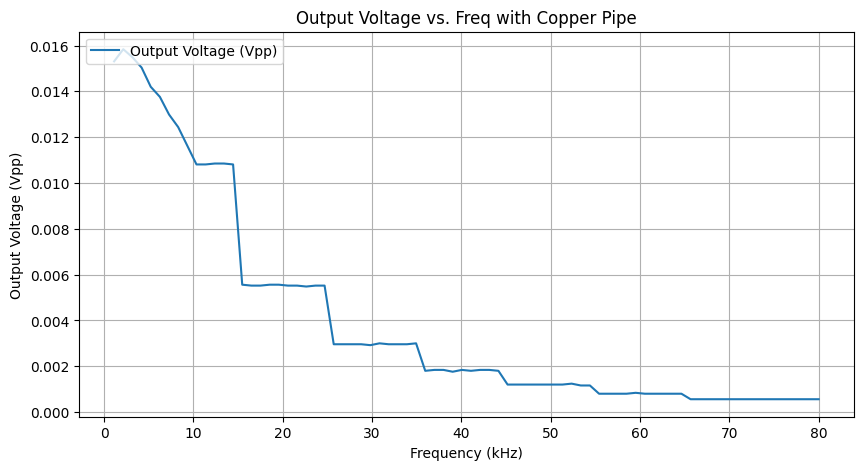

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

air_data = '../data/2026-01-27_12_48_44_copper.csv'
df = pd.read_csv(air_data)
df = df[1:]
df = df[df['Vpp_RX (V)'] < 1E37]
print(df.head(4))

plt.figure(figsize=(10, 5))
plt.plot(df['Freq (Hz)'] / 1000, df['Vpp_RX (V)'], label='Output Voltage (Vpp)')
# plt.plot(df['Freq (Hz)'], df['Vpp_TX (V)'], label='TX Coil Voltage (Vpp)')
# plt.plot(df['Freq (Hz)'] / 1000, df['Phase_Shift (deg)'] * (np.pi / 180), label='Relative Phase Shift (rad)')

plt.xlabel('Frequency (kHz)')
plt.ylabel('Output Voltage (Vpp)')
plt.title('Output Voltage vs. Freq with Copper Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()



## Session 3: Jan 27th, 2026

#### Today's goals:
- Plot the experimental vs. expected amplitude ratio and phase shifts for aluminium and copper

#### Plot expected values

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

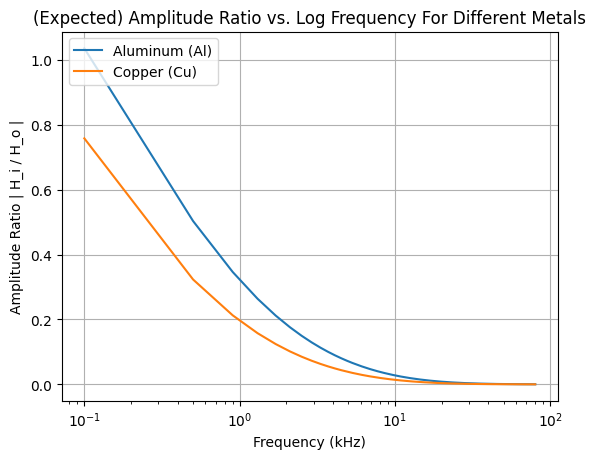

Figure 1: Expected amplitude ratio for aluminum and copper pipes, plotted as a function of log frequency


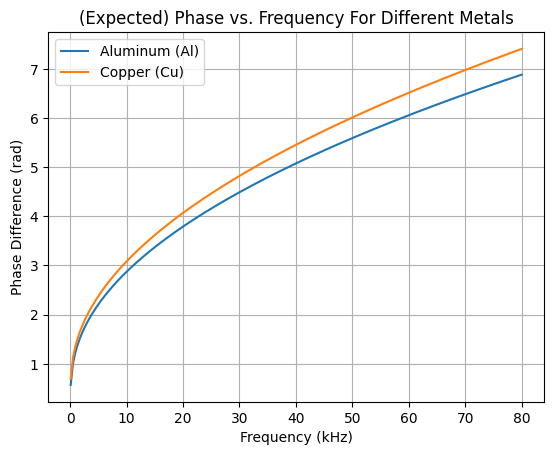

Figure 2: Expected phase difference for aluminum and copper pipes, plotted as a function of frequency


In [135]:
import numpy as np

# Parameters
al_sig = 3e7
al_mu = 1.256e-6
al_outer_r = 25.59e-3 / 2
al_inner_r = 21.61e-3 / 2
cu_sig = 5.96e7
cu_mu = 1.256e-6
cu_outer_r = 28.61e-3 / 2
cu_inner_r = 25.55e-3 / 2 

# Create underlying freq scale
max_freq = 80e3
min_freq = 100
freq = np.linspace(min_freq, max_freq, 200)

# Calculate k0 propagation constant 
al_k0 = np.sqrt(2 * np.pi * freq * al_sig * al_mu / 2)
cu_k0 = np.sqrt(2 * np.pi * freq * cu_sig * cu_mu / 2)

# Calculate rho for amplitude ratio 
al_rho = 2 * np.sqrt(al_outer_r / al_inner_r) * \
    (np.exp(-al_k0 * (al_outer_r - al_inner_r)) / \
     np.sqrt(1 + (al_inner_r * al_k0) + (al_inner_r**2 * al_k0**2/2)))

cu_rho = 2 * np.sqrt(cu_outer_r / cu_inner_r) * \
    (np.exp(-cu_k0 * (cu_outer_r - cu_inner_r)) / \
     np.sqrt(1 + (cu_inner_r * cu_k0) + (cu_inner_r**2 * cu_k0**2/2)))

# Calculate phase
al_phi = al_k0 * (al_outer_r - al_inner_r) + \
    np.arctan((al_inner_r * al_k0) / (2 + al_inner_r * al_k0))

cu_phi = cu_k0 * (cu_outer_r - cu_inner_r) + \
    np.arctan((cu_inner_r * cu_k0) / (2 + cu_inner_r * cu_k0))

# Calculate full amplitude ratio
al_amp_ratio = al_rho * np.exp(1j * al_phi)
cu_amp_ratio = cu_rho * np.exp(1j * cu_phi)

# Plot expected values as graphs
plt.figure()
plt.plot(freq / 1e3, np.abs(al_amp_ratio), label='Aluminum (Al)')
plt.plot(freq / 1e3, np.abs(cu_amp_ratio), label='Copper (Cu)')
plt.title('(Expected) Amplitude Ratio vs. Log Frequency For Different Metals')
plt.xlabel('Frequency (kHz)')
plt.xscale('log')
plt.ylabel('Amplitude Ratio | H_i / H_o |')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()
print("Figure 1: Expected amplitude ratio for aluminum and copper pipes, plotted as a function of log frequency")

plt.figure()
plt.plot(freq / 1e3, al_phi, label='Aluminum (Al)')
plt.plot(freq / 1e3, cu_phi, label='Copper (Cu)')
plt.title('(Expected) Phase vs. Frequency For Different Metals')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase Difference (rad)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()
print("Figure 2: Expected phase difference for aluminum and copper pipes, plotted as a function of frequency")


#### Load experimental data

In [136]:
air_data = '../data/2026-01-20_13_55_01_air.csv'
al_data = '../data/2026-01-27_11_28_26_aluminum.csv'
cu_data = '../data/2026-01-27_12_48_44_copper.csv'

air_df = pd.read_csv(air_data)
air_df = air_df[air_df['Vpp_RX (V)'] < 1E37]

al_df = pd.read_csv(al_data)
al_df = al_df[al_df['Vpp_RX (V)'] < 1E37]

cu_df = pd.read_csv(cu_data)
cu_df = cu_df[cu_df['Vpp_RX (V)'] < 1E37]

#### Plot experimental data against expected values

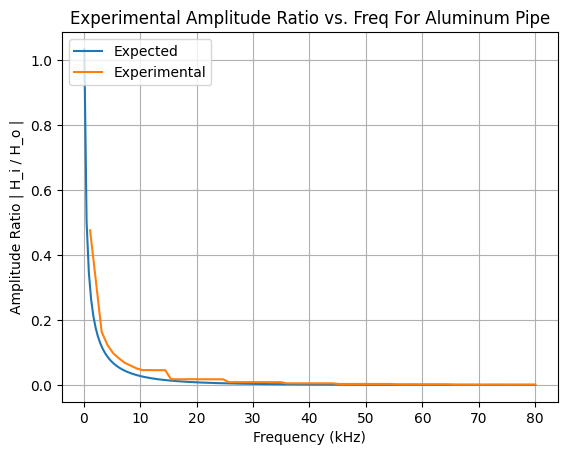

Figure 3: Comparing experimental amplitude ratio of aluminum against expected ratio


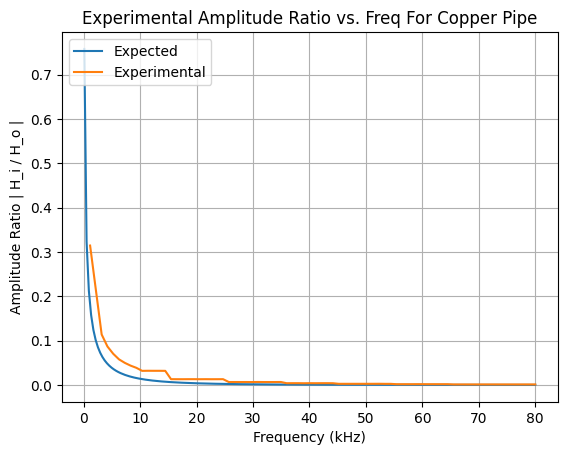

Figure 3: Comparing experimental amplitude ratio of copper against expected ratio


In [137]:
# Find experimental amplitude ratios
al_meas_amp_ratio = np.array(al_df['Vpp_RX (V)']) / np.array(air_df['Vpp_RX (V)']) 
cu_meas_amp_ratio = np.array(cu_df['Vpp_RX (V)']) / np.array(air_df['Vpp_RX (V)'])

plt.figure()
plt.plot(freq / 1e3, np.abs(al_amp_ratio), label='Expected')
plt.plot(air_df['Freq (Hz)'] / 1e3, al_meas_amp_ratio, label='Experimental')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude Ratio | H_i / H_o |')
plt.title('Experimental Amplitude Ratio vs. Freq For Aluminum Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()
print("Figure 3: Comparing experimental amplitude ratio of aluminum against expected ratio")

plt.figure()
plt.plot(freq / 1e3, np.abs(cu_amp_ratio), label='Expected')
plt.plot(air_df['Freq (Hz)'] / 1e3, cu_meas_amp_ratio, label='Experimental')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude Ratio | H_i / H_o |')
plt.title('Experimental Amplitude Ratio vs. Freq For Copper Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()
print("Figure 3: Comparing experimental amplitude ratio of copper against expected ratio")


We can see from Figure 3 and 4 that our measurements match pretty closely with the expected solution - at least for the amplitude ratio. I just wished I collected more data in the the lower frequency range. The reason I didn't prioritize this was because I thought we only needed to collect data for frequencies above the breakdown point... 

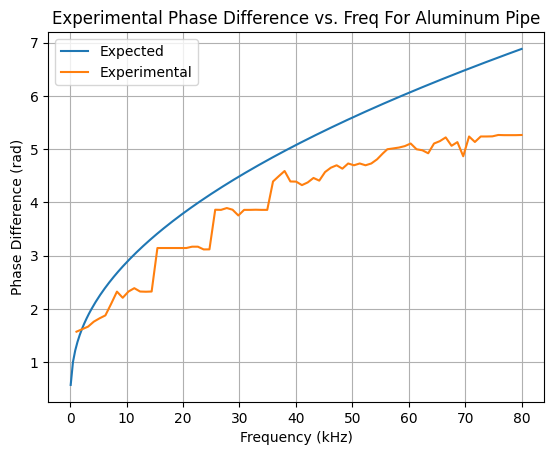

Figure 5: Comparing experimental phase difference of aluminum against expected value


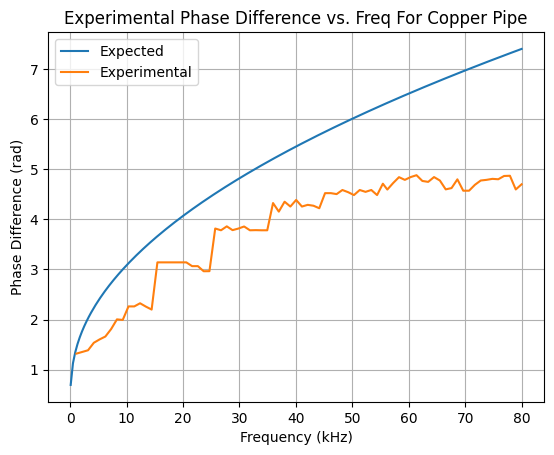

Figure 6: Comparing experimental phase difference of copper against expected value


In [138]:
# Find experimental phase differences
air_phase = air_df['Phase_Shift (deg)'].values
al_phase = al_df['Phase_Shift (deg)'].values
cu_phase = cu_df['Phase_Shift (deg)'].values

# Calculate and apply modulo
al_meas_phi = np.deg2rad(air_phase - al_phase) % (2 * np.pi)
cu_meas_phi = np.deg2rad(air_phase - cu_phase) % (2 * np.pi)

plt.figure()
plt.plot(freq / 1e3, al_phi, label='Expected')
plt.plot(air_df['Freq (Hz)'] / 1e3, al_meas_phi, label='Experimental')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase Difference (rad)')
plt.title('Experimental Phase Difference vs. Freq For Aluminum Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()
print("Figure 5: Comparing experimental phase difference of aluminum against expected value")

plt.figure()
plt.plot(freq / 1e3, cu_phi, label='Expected')
plt.plot(air_df['Freq (Hz)'] / 1e3, cu_meas_phi, label='Experimental')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase Difference (rad)')
plt.title('Experimental Phase Difference vs. Freq For Copper Pipe')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()
print("Figure 6: Comparing experimental phase difference of copper against expected value")


From Figure 5 and 6, we see that our measured phase difference doesn't fit the expected trend as well as the amplitude ratio. Collecting the phase data was a little bit difficult, often times resulting in NaN 9.9E37 values. I thought I improved this after extending the time scale so that the active buffer held more periods of data to run computations on... but the accuracy of this data seems to deteriorate at higher frequencies, which is likely due to noise and external EMI. The lab manual did say to take extra measurements at higher frequencies until the data stabilized, which I regret not doing.

## Post-Lab: Feb 8th, 2026

#### Perform non-linear least squares fit

Aluminum:
	Fitted conductivity: 2.870000E+07 S/m
	Expected conductivity: 3.000000E+07 S/m


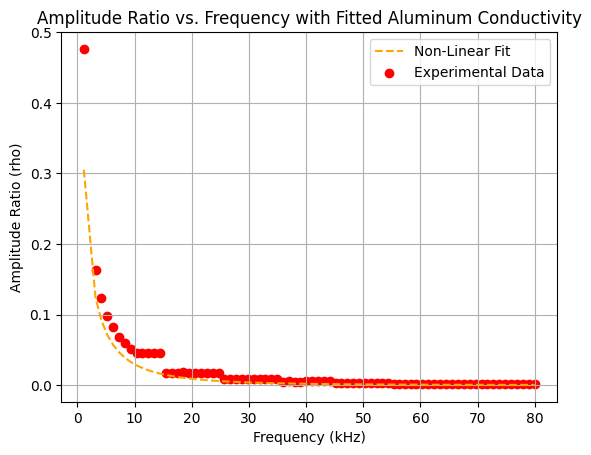

Figure 7: Showing results of non-linear least squares fit on aluminum data
Copper:
	Fitted conductivity: 4.570000E+07 S/m
	Expected conductivity: 5.960000E+07 S/m


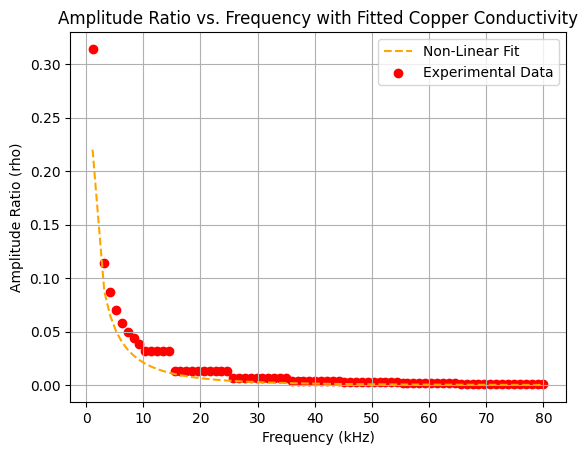

Figure 7: Showing results of non-linear least squares fit on copper data


In [ ]:
from scipy.optimize import least_squares

# Fitting on rho to find conductance for aluminum
def al_amplitude_residual(params):
    sig = params[0] # Extract conductance variable to optimize
    k0 = np.sqrt(2 * np.pi * np.array(air_df['Freq (Hz)']) * sig * al_mu / 2)
    rho = 2 * np.sqrt(al_outer_r / al_inner_r) * \
    (np.exp(-k0 * (al_outer_r - al_inner_r)) / \
     np.sqrt(1 + (al_inner_r * k0) + (al_inner_r**2 * k0**2/2)))
    return rho - al_meas_amp_ratio

# Perform non-linear fit
al_initial_guess = [1e7]
al_res = least_squares(al_amplitude_residual, al_initial_guess)
al_fitted_sig = al_res.x[0]
print(f"Aluminum:")
print(f"\tFitted conductivity: {al_fitted_sig:E} S/m")
print(f"\tExpected conductivity: {al_sig:E} S/m")

# Re-compute amplitude ratio using fitted value
al_fitted_k0 = np.sqrt(2 * np.pi * np.array(air_df['Freq (Hz)']) * al_fitted_sig * al_mu / 2)
al_fitted_rho = 2 * np.sqrt(al_outer_r / al_inner_r) * \
(np.exp(-al_fitted_k0 * (al_outer_r - al_inner_r)) / \
    np.sqrt(1 + (al_inner_r * al_fitted_k0) + (al_inner_r**2 * al_fitted_k0**2/2)))

# Plot to see if it actually fits the measured data 
plt.figure()
plt.plot(air_df['Freq (Hz)'] / 1e3, al_fitted_rho, linestyle="dashed", color="orange", label="Non-Linear Fit")
plt.scatter(air_df['Freq (Hz)'] / 1e3, al_meas_amp_ratio, label="Experimental Data", color="red")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude Ratio (rho)")
plt.title("Amplitude Ratio vs. Frequency with Fitted Aluminum Conductivity")
plt.legend()
plt.grid()
plt.show()
print(f"Figure 7: Showing results of non-linear least squares fit on aluminum data")

# Fitting on rho to find conductance for copper
def cu_amplitude_residual(params):
    sig = params[0] # Extract conductance variable to optimize
    k0 = np.sqrt(2 * np.pi * np.array(air_df['Freq (Hz)']) * sig * cu_mu / 2)
    rho = 2 * np.sqrt(cu_outer_r / cu_inner_r) * \
    (np.exp(-k0 * (cu_outer_r - cu_inner_r)) / \
     np.sqrt(1 + (cu_inner_r * k0) + (cu_inner_r**2 * k0**2/2)))
    return rho - cu_meas_amp_ratio

# Perform non-linear fit
cu_initial_guess = [1e7]
cu_res = least_squares(cu_amplitude_residual, cu_initial_guess)
cu_fitted_sig = cu_res.x[0]
print(f"Copper:")
print(f"\tFitted conductivity: {cu_fitted_sig:E} S/m")
print(f"\tExpected conductivity: {cu_sig:E} S/m")

# Re-compute amplitude ratio using fitted value
cu_fitted_k0 = np.sqrt(2 * np.pi * np.array(air_df['Freq (Hz)']) * cu_fitted_sig * cu_mu / 2)
cu_fitted_rho = 2 * np.sqrt(cu_outer_r / cu_inner_r) * \
(np.exp(-cu_fitted_k0 * (cu_outer_r - cu_inner_r)) / \
    np.sqrt(1 + (cu_inner_r * cu_fitted_k0) + (cu_inner_r**2 * cu_fitted_k0**2/2)))

# Plot to see if it actually fits the measured data 
plt.figure()
plt.plot(air_df['Freq (Hz)'] / 1e3, cu_fitted_rho, linestyle="dashed", color="orange", label="Non-Linear Fit")
plt.scatter(air_df['Freq (Hz)'] / 1e3, cu_meas_amp_ratio, label="Experimental Data", color="red")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude Ratio (rho)")
plt.title("Amplitude Ratio vs. Frequency with Fitted Copper Conductivity")
plt.legend()
plt.grid()
plt.show()
print(f"Figure 7: Showing results of non-linear least squares fit on copper data")



Hmm, the fitted conductivity values deviate slightly from the theoretical values. The fitted aluminum conductivity is half as small as the expected value, and the copper fit is better - but still has an error of 32%.

The conductivities are off, but the overall model seems to fit the experimental data pretty well (especially at higher frequencies).
This means the issue isn't on the analysis side but likely to do with data collection errors or the metal pipes themselves. A TA made a comment about the actual conductivity of the pipes decreasing overtime due to mechanical wear and tear. Discussing with my lab partner, we concluded rust may also be a source of error on the interior of the copper pipe.

#### Calculating skin depth
Using the fitted conductivity values found above, it'll be interesting to finally compute the skin depth for copper and aluminum at set frequencies. The prof suggested it would be good to compare against experimental values available online. For a quick sanity check, I'll be computing the skin depth at 10 kHz since I found some readily available data on Wikipedia

Skin depth: $$ \delta = \frac{1}{k_0} = \sqrt{\frac{2}{w\sigma\mu}}$$

<img src="../assets/skin_depth.png" height="600" alt="Experimental skin depth table"/>

In [153]:
def compute_skin_depth(frequency, metal):
    if metal == 'al':
        return np.sqrt(2 / (2 * np.pi * frequency * al_fitted_sig * al_mu))
    elif metal == 'cu':
        return np.sqrt(2 / (2 * np.pi * frequency * cu_fitted_sig * cu_mu))

al_skin_depth = compute_skin_depth(10e3, 'al')
cu_skin_depth = compute_skin_depth(10e3, 'cu')
print(f"Aluminum skin depth @10 kHz: {al_skin_depth:E} m = {al_skin_depth * 1e6} um")
print(f"Copper skin depth @10 kHz: {cu_skin_depth:E} m = {cu_skin_depth * 1e6} um")


Aluminum skin depth @10 kHz: 9.397001E-04 m = 939.7001487138066 um
Copper skin depth @10 kHz: 7.446842E-04 m = 744.684207583985 um


The skin depths for both aluminum and copper at 10 kHz are the correct order of magnitude, but $\pm$ 200 um from the correct value. If I had more time, I would go back to recollect some lower frequency data for copper and aluminum so that the non-linear fit produces a more accurate conductivity. 